# FordA - mLSTM Anomaly Detection

Engine fault detection from vibration time series.
A Daubechies-4 DWT decomposes each signal into approximation (cA) and detail (cD) coefficients,
giving a 2-channel input of half the original length.
The mLSTM autoencoder is trained on normal engine signals only.

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import auc, roc_curve

from anomdet.data import load_dataset, make_loader
from anomdet.evaluate import compute_scores, evaluate
from anomdet.explain import plot_reconstruction, shap_timeseries
from anomdet.model import MLSTMAutoencoder
from anomdet.train import train

## Data

FordA: class `1` = normal engine, class `-1` = fault.
DWT (db4) reduces 500 time steps to 253 approximation/detail pairs.

In [2]:
X_train, y_train = load_dataset('FordA', split='train', normal_label='1', use_dwt=True)

n_normal = int((y_train == 0).sum())
n_anom   = int((y_train == 1).sum())
print(f'Shape: {X_train.shape}  (n, T, C)')
print(f'Normal: {n_normal}   Anomaly: {n_anom}')

Shape: torch.Size([3601, 253, 2])  (n, T, C)
Normal: 1755   Anomaly: 1846


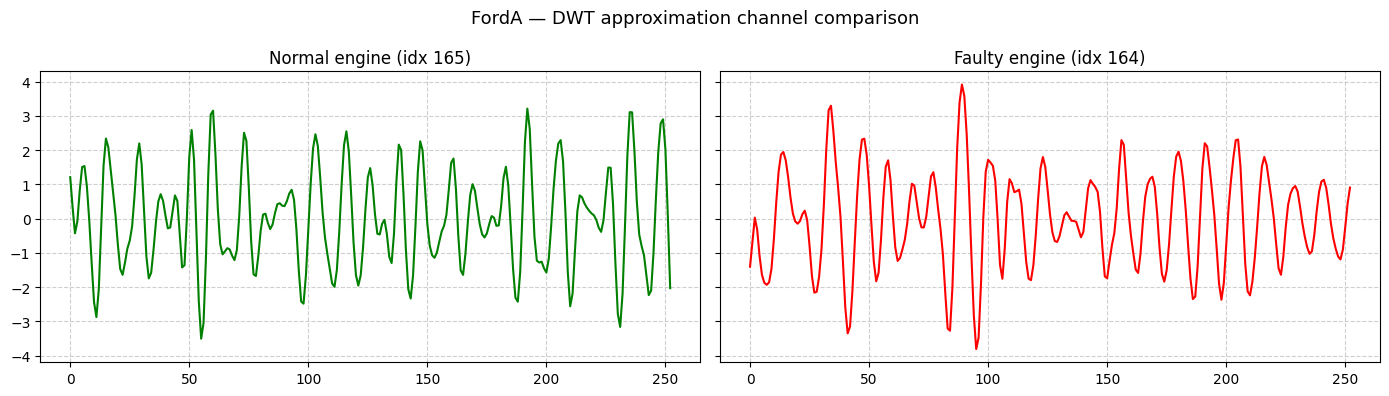

In [3]:
norm_idx = random.choice(np.where(y_train == 0)[0])
anom_idx = random.choice(np.where(y_train == 1)[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

# channel 0 = approximation coefficients (cA)
axes[0].plot(X_train[norm_idx, :, 0], color='green')
axes[0].set_title(f'Normal engine (idx {norm_idx})')
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(X_train[anom_idx, :, 0], color='red')
axes[1].set_title(f'Faulty engine (idx {anom_idx})')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('FordA — DWT approximation channel comparison', fontsize=13)
plt.tight_layout()
plt.show()

## Model

In [4]:
device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Device: {device}')

seq_len = X_train.shape[1]  # 253
in_dim  = X_train.shape[2]  # 2

model = MLSTMAutoencoder(
    seq_len=seq_len,
    in_dim=in_dim,
    d_model=64,
    latent_dim=8,
    enc_blocks=2,
    dec_blocks=2,
).to(device)

print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Device: cuda
Parameters: 122,154


## Training

AdamW + MSE loss + gradient clipping at 1.0. The loader filters to normal samples only.

In [5]:
loader = make_loader(X_train, y_train, batch_size=64, device=device)

loss_history = train(
    model, loader,
    epochs=50,
    lr=1e-3,
    weight_decay=1e-4,
    device=device,
)

Training: 100%|█████████████████████████████████████████████████████| 50/50 [02:33<00:00,  3.06s/ep]


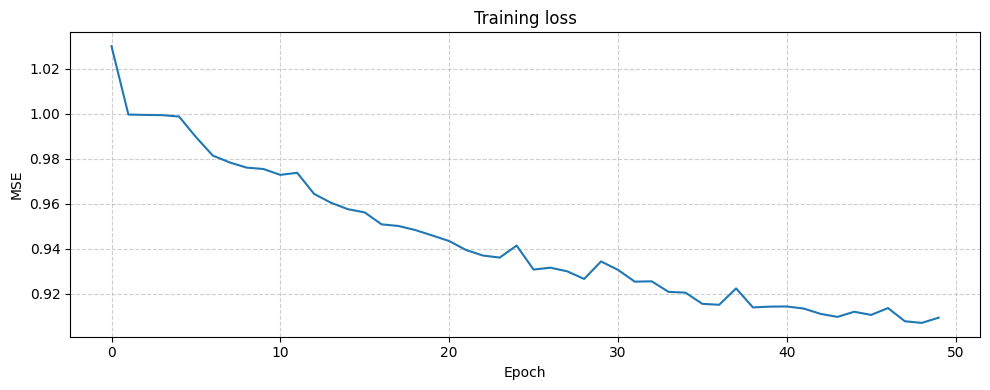

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(loss_history, linewidth=1.5, color='#1f77b4')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Training loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Evaluation

Anomaly score = mean per-sample MSE on the held-out test set.
Threshold is selected by maximising Youden's J (TPR - FPR) on the same split.

In [7]:
X_test, y_test = load_dataset('FordA', split='test', normal_label='1', use_dwt=True)

scores  = compute_scores(model, X_test, device)
metrics = evaluate(scores, y_test)

auroc  = metrics['auroc']
auprc  = metrics['auprc']
thresh = metrics['threshold']

print(f'AUROC:     {auroc:.4f}')
print(f'AUPRC:     {auprc:.4f}')
print(f'Threshold: {thresh:.6f}')

AUROC:     0.5475
AUPRC:     0.5899
Threshold: 0.974864


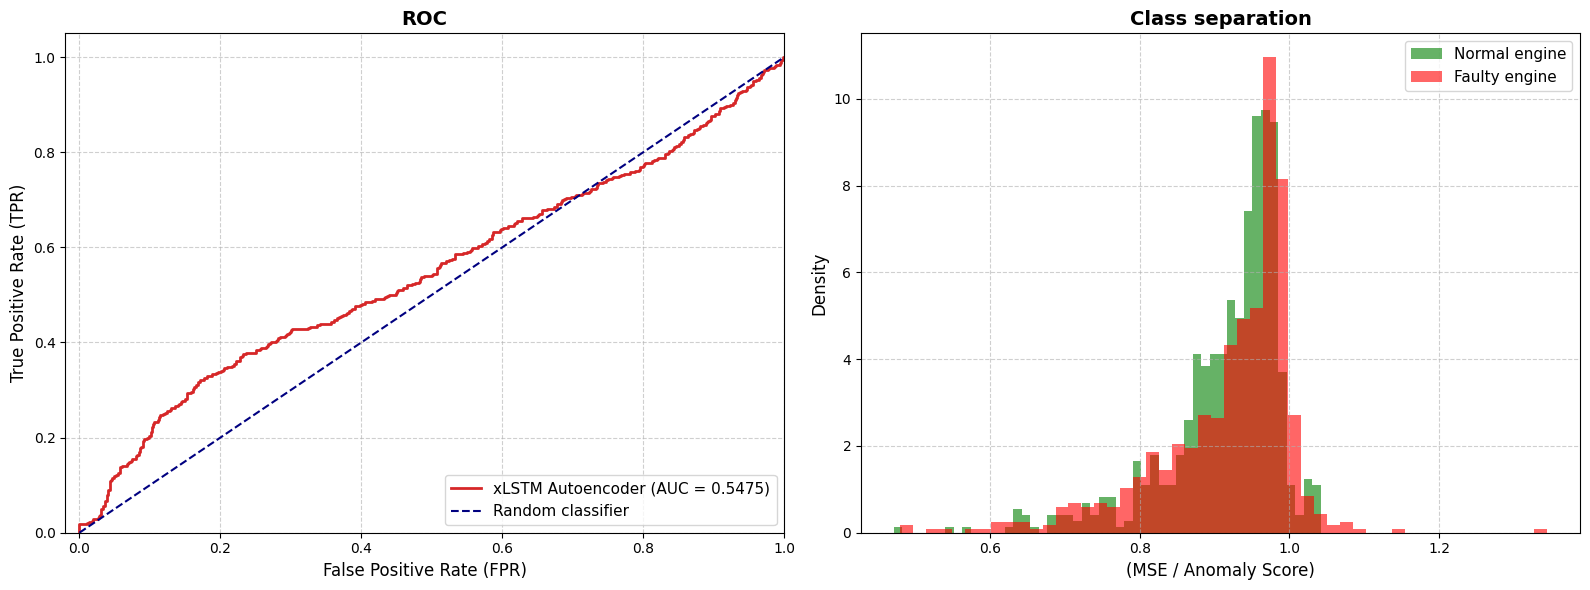

In [8]:
fpr, tpr, _ = roc_curve(y_test, scores)
roc_auc = auc(fpr, tpr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(fpr, tpr, color='#d62728', lw=2, label=f'xLSTM Autoencoder (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], 'navy', linestyle='--', lw=1.5, label='Random classifier')
ax1.set_xlim([-0.02, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax1.set_ylabel('True Positive Rate (TPR)', fontsize=12)
ax1.set_title('ROC', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.6)

normal_scores = scores[y_test == 0]
anom_scores   = scores[y_test == 1]

ax2.hist(normal_scores, bins=50, alpha=0.6, color='green', density=True, label='Normal engine')
ax2.hist(anom_scores,   bins=50, alpha=0.6, color='red',   density=True, label='Faulty engine')
ax2.set_xlabel('(MSE / Anomaly Score)', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Class separation', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Error Map

Per-step MSE on the approximation channel. Orange shading = top 15% error region.

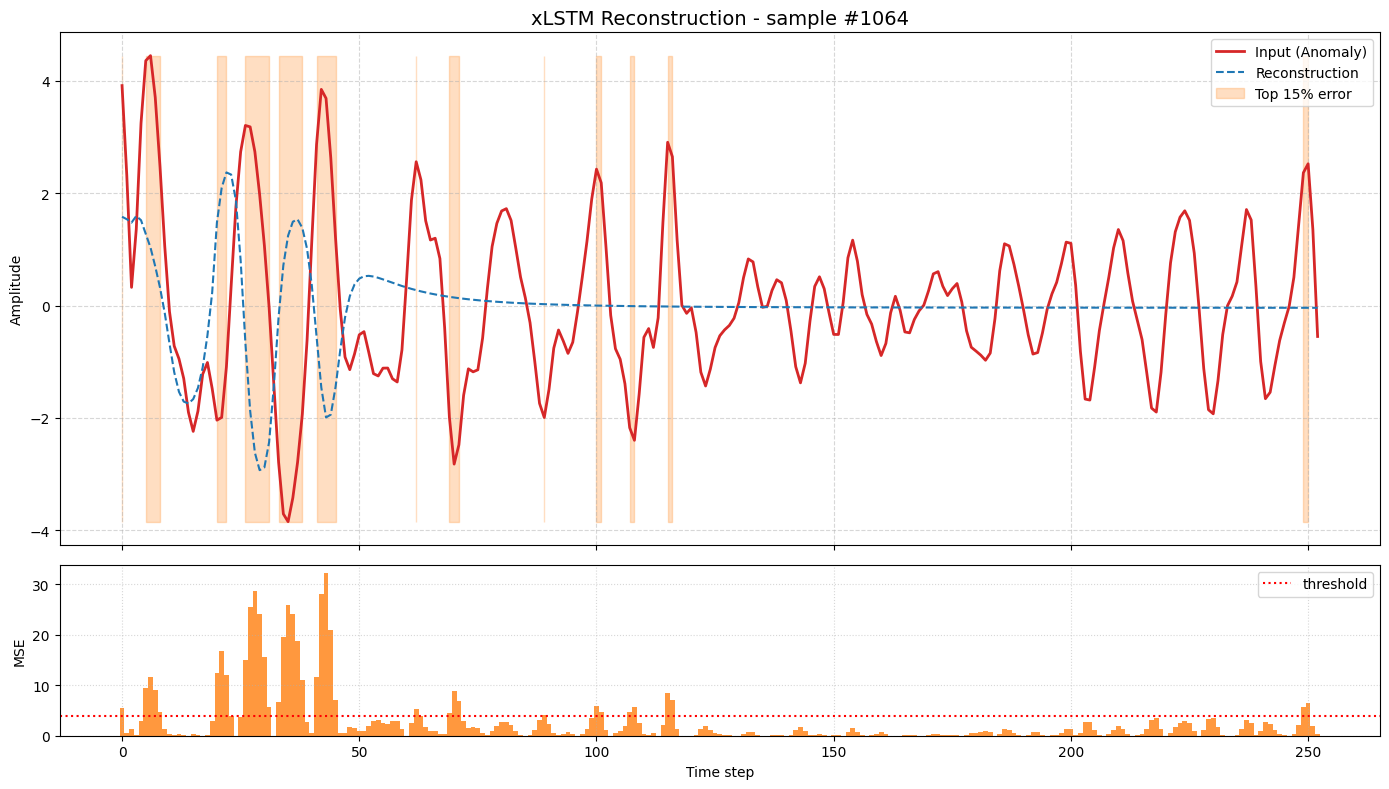

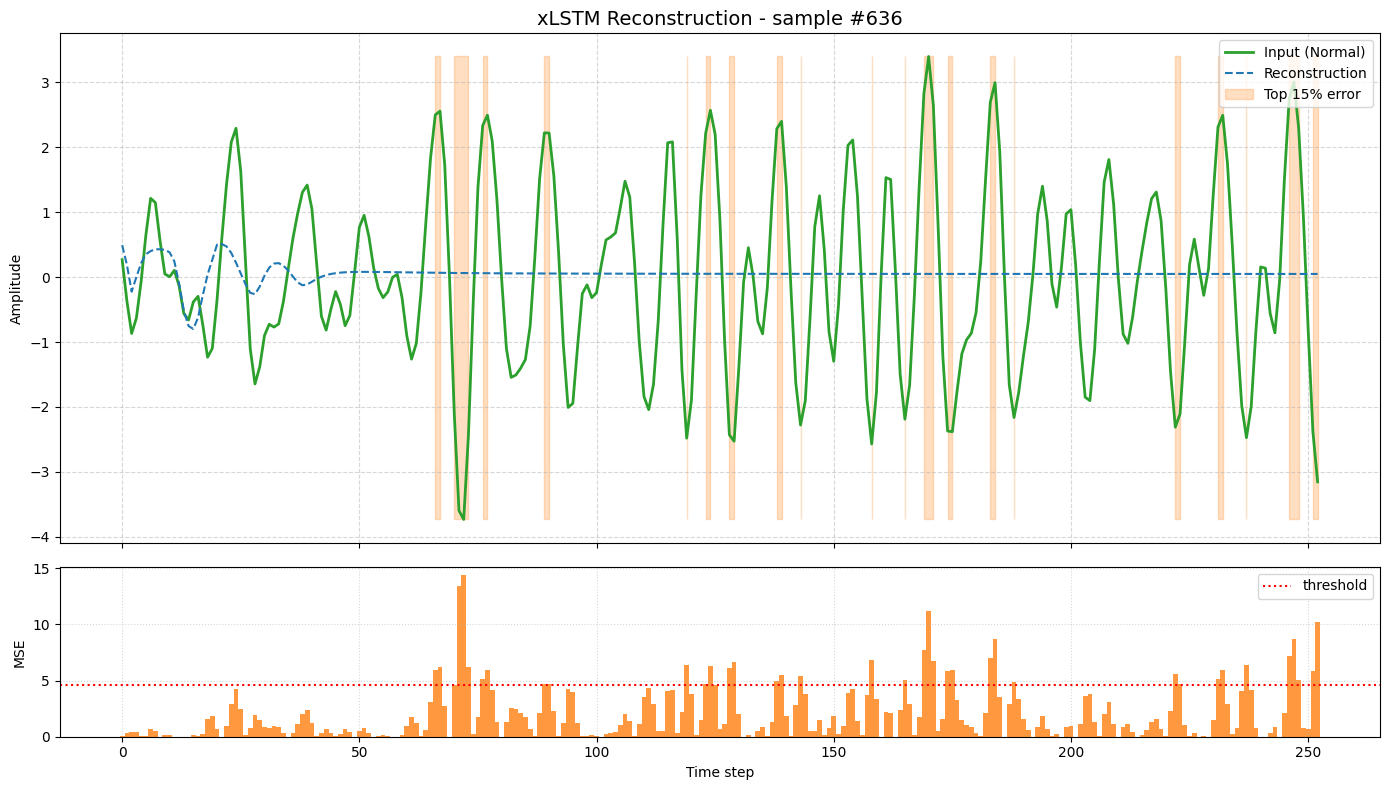

In [9]:
anom_indices = np.where(y_test == 1)[0]
norm_indices = np.where(y_test == 0)[0]

worst_anom = int(anom_indices[np.argmax(scores[anom_indices])])
rand_norm  = int(random.choice(norm_indices))

for idx in [worst_anom, rand_norm]:
    plot_reconstruction(model, X_test, y_test, index=idx, device=device)

## SHAP

KernelSHAP on the approximation channel (cA). Red = pushes anomaly score up, blue = pulls it down.
Background = 50 normal samples.

In [10]:
background     = X_test[y_test == 0][:50].numpy()   # (50, T, C)
explain_sample = X_test[[worst_anom]].numpy()        # (1, T, C)

shap_vals = shap_timeseries(model, background, explain_sample, device)
# shap_vals.shape: (1, T, C)

  0%|          | 0/1 [00:00<?, ?it/s]

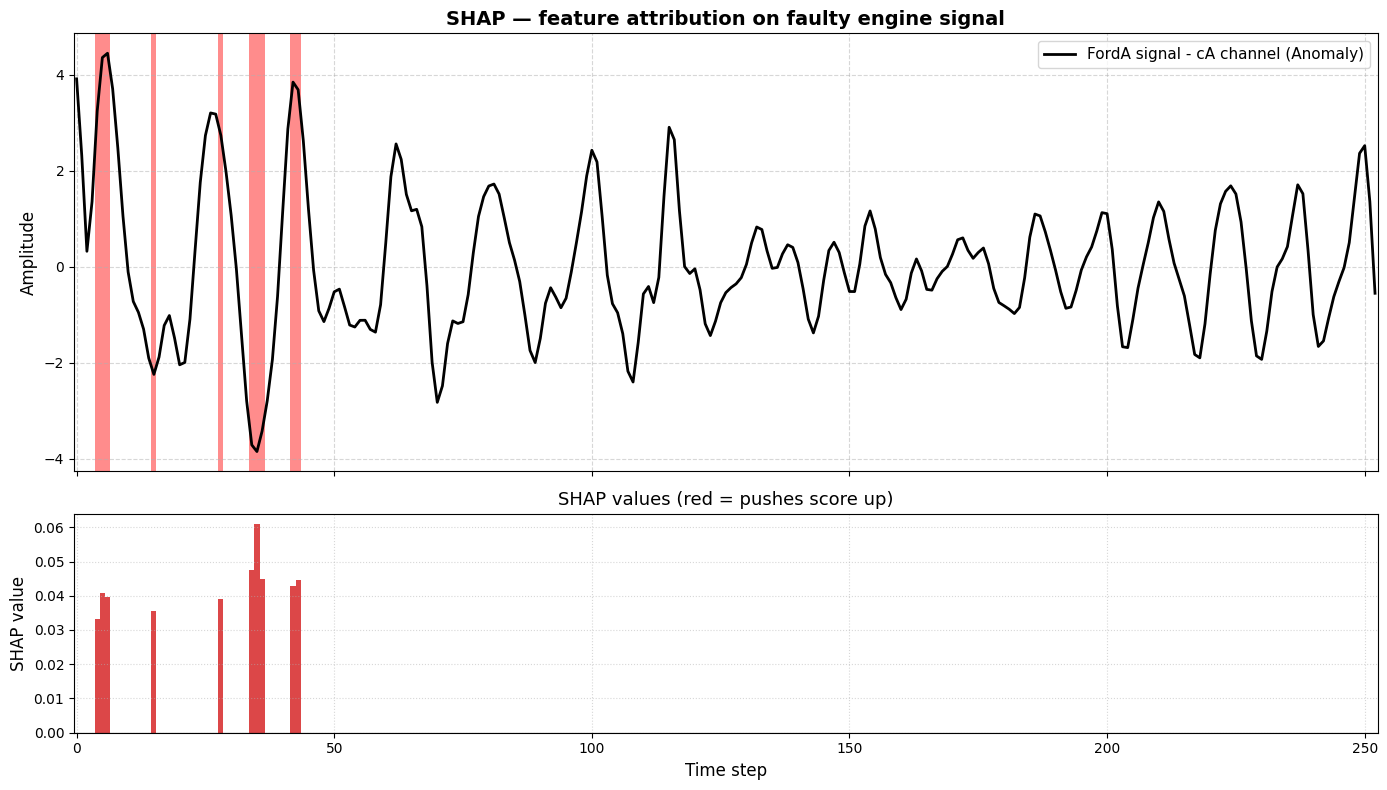

In [11]:
# visualise approximation channel (cA)
signal = explain_sample[0, :, 0]
sv     = shap_vals[0, :, 0]
time   = np.arange(len(signal))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(time, signal, color='black', linewidth=2, label='FordA signal - cA channel (Anomaly)')
max_abs = np.abs(sv).max() + 1e-9
for t in time:
    color = 'red' if sv[t] > 0 else 'blue'
    ax1.axvspan(t - 0.5, t + 0.5, color=color, alpha=min(abs(sv[t]) / max_abs, 0.45), lw=0)
ax1.set_title('SHAP — feature attribution on faulty engine signal', fontsize=14, fontweight='bold')
ax1.set_ylabel('Amplitude', fontsize=12)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

colors = ['#d62728' if v > 0 else '#1f77b4' for v in sv]
ax2.bar(time, sv, color=colors, width=1.0, alpha=0.85)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('SHAP values (red = pushes score up)', fontsize=13)
ax2.set_xlabel('Time step', fontsize=12)
ax2.set_ylabel('SHAP value', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.5)

plt.xlim(-0.5, len(signal) - 0.5)
plt.tight_layout()
plt.show()